In [1]:
import os, sys
from pathlib import Path

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle

from src.preprocess import preprocess_df
from src.network_model import NetworkModel
from src.kalman_network_tools import graphs_2_risk_scores

In [2]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Monday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')

df = preprocess_df(df_cic, date_col=' Timestamp')
print(df.shape)
df = df.iloc[:303_500, :].copy()
#df = df.iloc[300_000:303_500, :].copy()

(529481, 85)


In [12]:
from test_network_model_graph import generate_random_mvn_model, samples2flows
from src.network_model import get_mat_f_q_from_covariance

samples_df, cov = generate_random_mvn_model(n_entity=5, n_sample=10_000)
f_test, _ = get_mat_f_q_from_covariance(cov)

# Test with different parameters. 100 samples per flow give negligible error
# Convergence is observed. TODO: Gather error w.r.t parameter space
df_raw = samples2flows(samples_df, max_flow_sep=0.4, min_flow_per_sample=5, max_flow_per_sample=10,
                       src_feature_col=' Source Flow Attribute', dst_feature_col=' Destination Flow Attribute',
                       src_id_col=' Source ID', dst_id_col=' Destination ID')
df = preprocess_df(df_raw, date_col=' Timestamp')


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:09<00:00, 144.20it/s]


In [13]:
df

,Timestamp,Source ID,Destination ID,Source Flow Attribute,Destination Flow Attribute
0,2023-06-06 00:00:00.281,0,4,0.027326,0.077778
1,2023-06-06 00:00:00.581,0,4,0.027326,0.077778
2,2023-06-06 00:00:00.865,4,2,0.077778,0.382492
3,2023-06-06 00:00:01.226,2,0,0.382492,0.027326
4,2023-06-06 00:00:01.587,2,4,0.382492,0.077778
...,...,...,...,...,...
84971,2023-06-06 07:04:34.341,3,1,1.58829,2.565536
84972,2023-06-06 07:04:34.719,0,4,1.038166,1.487225
84973,2023-06-06 07:04:34.972,2,1,1.918302,2.565536
84974,2023-06-06 07:04:35.232,0,3,1.038166,1.58829


In [14]:
df.to_csv('test_flows.csv', index=False)

In [13]:
os.listdir('saves')

['attack_rel_nodes.pickle',
 'internal_nodes_tuesday.pickle',
 'monday_freq_1000.pickle',
 'partitioned_nodes.pickle',
 'partitioned_nodes_106.pickle',
 'risks01.pickle',
 'risks_insider.pickle',
 'sample_nodes.pickle',
 'sweep_friday_afternoon_ddos_180_1_2.pickle',
 'sweep_friday_afternoon_ps_180_1_2.pickle',
 'sweep_friday_tuesday_180_1_2.pickle',
 'sweep_tuesday_180_1_2.pickle',
 'sweep_tuesday_internal_180_1_2.pickle',
 'sweep_tuesday_internal_90_1_2.pickle',
 'tuesday_freq_1000.pickle',
 'validation_curves1.pickle',
 'victim_net.pickle',
 'victim_net2.pickle']

In [6]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
    entity_names = pickle.load(handle)
len(entity_names)

13

In [7]:
import importlib
import src.network_model

importlib.reload(src.network_model)
from src.network_model import *

Conditioning number:  3.3900564024158837 
Determinant of F^T*F:  0.9848011774715898


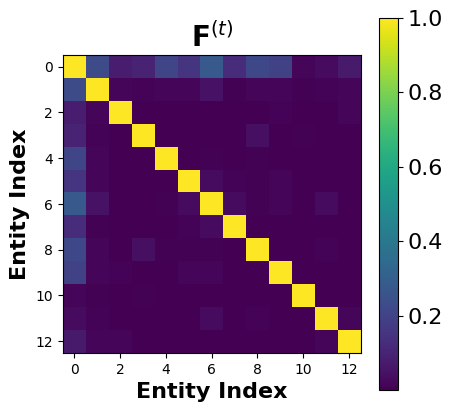

In [8]:
nm = NetworkModel()
nm.read_flows(df, conn_param='Num Packets Received', entity_names=entity_names,
             window_type= 'time', sync_window_size= 1.2, time_scale= 'sec')

nm.fit_graph_model(method = 'cov') # cov
nm.plot_f(labels=True)
mthd_name = 'Corr. Coeff.'

In [9]:
import importlib
import src.network_plotting

importlib.reload(src.network_plotting)
from src.network_plotting import *

C:\Users\bayer\PycharmProjects\NRE\src\network_plotting.py:395: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


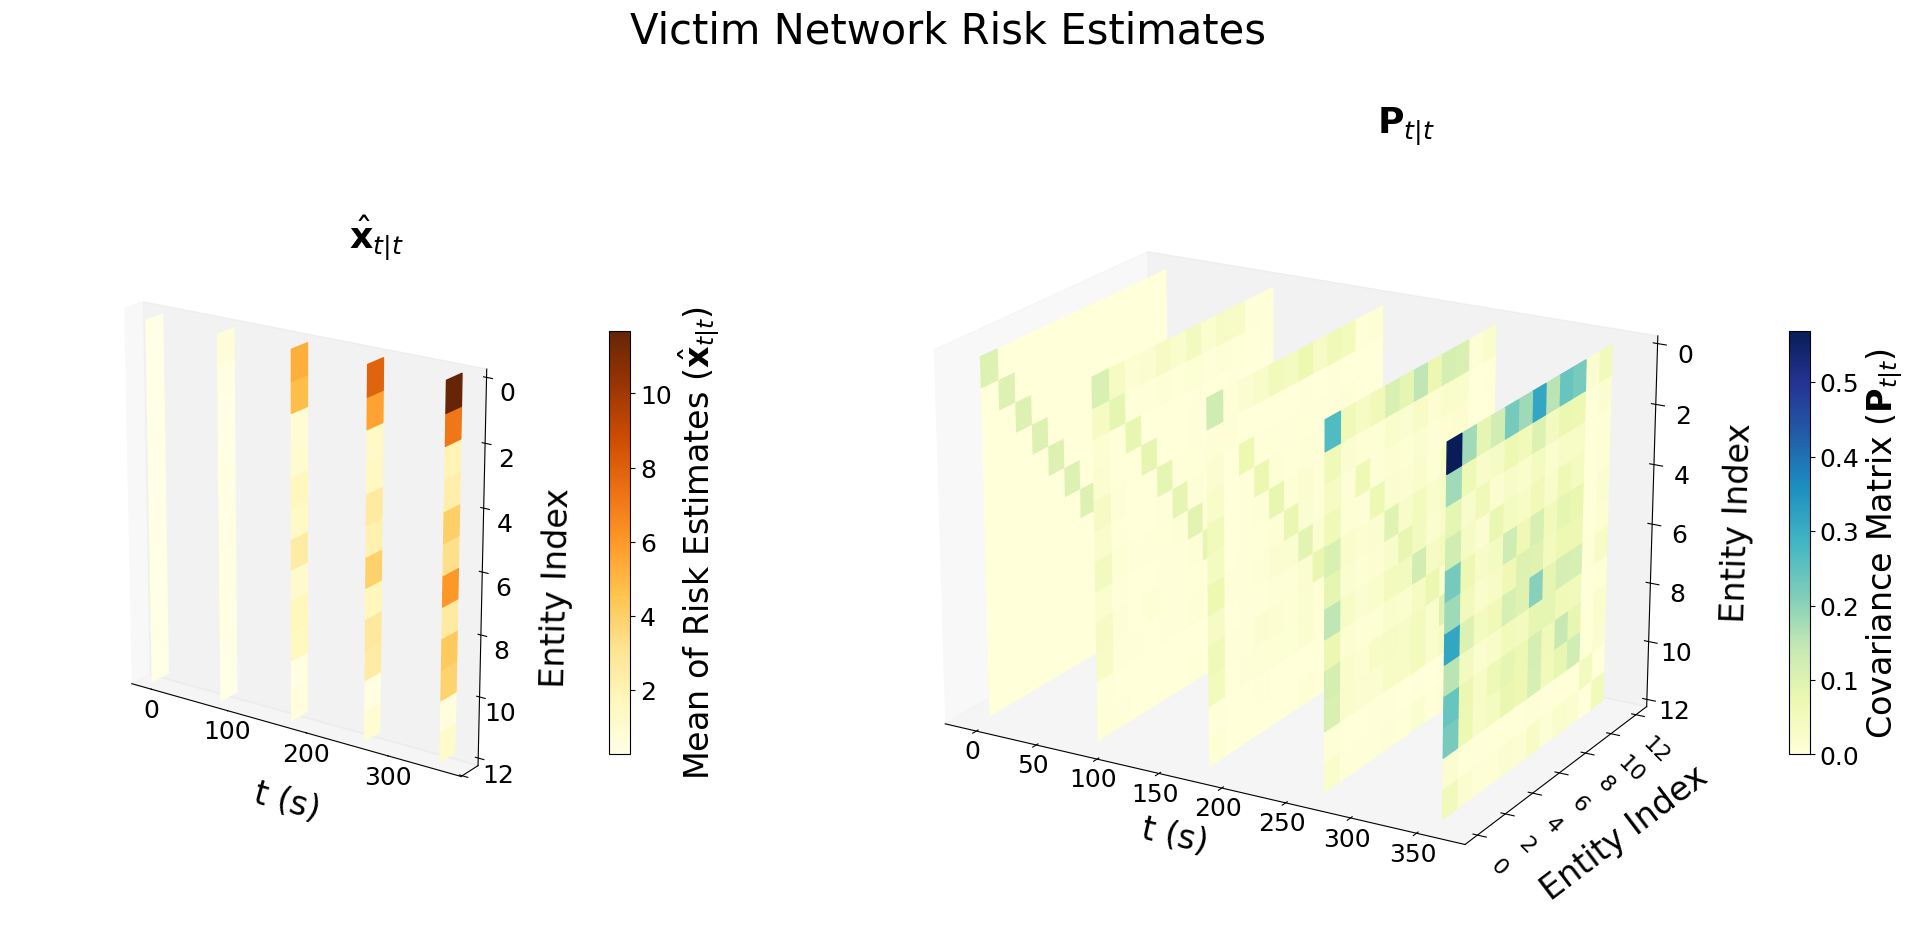

In [11]:
nn = 4
all_graphs = [nm.F for i in range(nn)]
all_graphs = np.array(all_graphs)
all_measurements = [None for _ in range(nn)]
all_measurements[1] = [5.6]
all_mat_h = [None for _ in range(nn)]
mat_h = np.zeros((1, len(entity_names)))
mat_h[0, 1] = 1
all_mat_h[1] = mat_h


x_list, P_list = graphs_2_risk_scores(all_graphs, all_measurements=all_measurements, all_mat_h=all_mat_h,
                                      k_steps=1, relief_factor=0.09, sequential=True, normalize=False, return_cov=True)
fig = risks_over_time_3d(x_list, P_list, t_graph=90, title='Victim Network Risk Estimates', save_name='saves/risk_ests_3d_v3.jpg')

In [14]:
entity_names

['192.168.10.3',
 '192.168.10.50',
 '192.168.10.51',
 '192.168.10.19',
 '192.168.10.17',
 '192.168.10.16',
 '192.168.10.12',
 '192.168.10.9',
 '192.168.10.5',
 '192.168.10.8',
 '192.168.10.14',
 '192.168.10.15',
 '192.168.10.25']

In [15]:
entity_names[6:10]

['192.168.10.12', '192.168.10.9', '192.168.10.5', '192.168.10.8']

In [94]:
x_list

[array([[0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954],
        [0.2767954]]),
 array([[0.74549567],
        [0.38678861],
        [0.31306499],
        [0.32395071],
        [0.34548351],
        [0.34037686],
        [0.39961282],
        [0.32600578],
        [0.36200185],
        [0.35036139],
        [0.28564991],
        [0.30419061],
        [0.31339101]]),
 array([[1.3464055 ],
        [0.61574066],
        [0.38891822],
        [0.42360257],
        [0.51620606],
        [0.48165926],
        [0.66373808],
        [0.44020321],
        [0.55381828],
        [0.52118579],
        [0.30201317],
        [0.35177629],
        [0.38779925]]),
 array([[2.24060705],
        [1.00853738],
        [0.51909124],
        [0.5956378 ],
        [0.82064075],
        [0.72916197],
        [1.118867

# Real-Time Example

In [16]:
import importlib
import src.real_time_model

importlib.reload(src.real_time_model)
from src.real_time_model import *

In [14]:
import importlib
import src.kalman_network_tools

importlib.reload(src.kalman_network_tools)
from src.kalman_network_tools import *

In [17]:
unit = NetworkUnit(entity_names)
x, p = unit.update_new_tick(df.iloc[:100] )

Conditioning number:  1681.3849482472222 
Determinant of F^T*F:  0.0067830854461217


In [18]:
x

array([[0.19022976],
       [0.25515952],
       [0.11094004],
       [0.11094004],
       [0.15579113],
       [0.25209915],
       [0.14408677],
       [0.13691365],
       [0.11094004],
       [0.11094004],
       [0.11094004],
       [0.11094004],
       [0.20189837]])